# DESCRIPTIVE STATISTICS ON HOUSING DATASET

We will be working with our cleaned housing dataset on kaggle its available on my github so lets import the required library and the dataset

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

In [3]:
df=r"C:\Users\ADMIN\Downloads\cleaned_housing_dataset.csv"
housing=pd.read_csv(df)
housing

,Unnamed: 0,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,1,13300000,7420,4,2,3,0,1,1,1,0,2,0,0
1,2,12250000,8960,4,4,4,0,1,1,1,0,3,1,0
2,3,12250000,9960,3,2,2,0,1,0,1,1,2,0,1
3,4,12215000,7500,4,2,2,0,1,0,1,0,3,0,0
4,5,11410000,7420,4,1,2,0,0,0,1,0,2,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,541,1820000,3000,2,1,1,0,1,0,1,1,2,1,2
541,542,1767150,2400,3,1,1,1,1,1,1,1,0,1,1
542,543,1750000,3620,2,1,1,0,1,1,1,1,0,1,2
543,544,1750000,2910,3,1,1,1,1,1,1,1,0,1,0


Lets start by removing the unnamed column

In [8]:
housing


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,0,1,1,1,0,2,0,0
1,12250000,8960,4,4,4,0,1,1,1,0,3,1,0
2,12250000,9960,3,2,2,0,1,0,1,1,2,0,1
3,12215000,7500,4,2,2,0,1,0,1,0,3,0,0
4,11410000,7420,4,1,2,0,0,0,1,0,2,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,0,1,0,1,1,2,1,2
541,1767150,2400,3,1,1,1,1,1,1,1,0,1,1
542,1750000,3620,2,1,1,0,1,1,1,1,0,1,2
543,1750000,2910,3,1,1,1,1,1,1,1,0,1,0


# DESCRIPTIVE STATISTICS
Lets describe our dataset variables 

In [9]:
housing.describe()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.141284,0.822018,0.649541,0.954128,0.684404,0.693578,0.765138,1.069725
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.348635,0.382849,0.477552,0.209399,0.465180,0.861586,0.424302,0.761373
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.000000,1.000000,2.000000


From this we can see the mean and standard deviation for each variables this is a good description

# PROBABILITY DISTRIBUTIONS

Lets check the probability of each house with their bedroom using an histogram plot

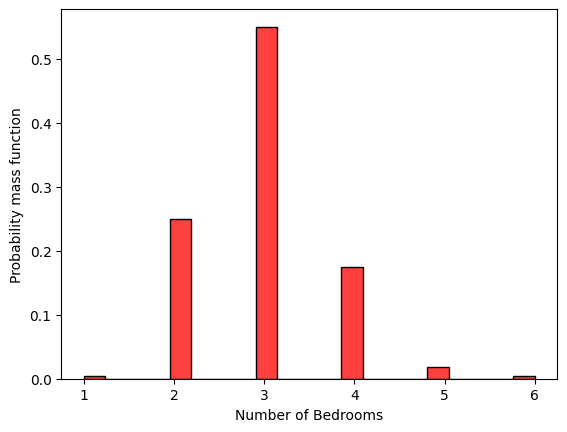

In [12]:
sns.histplot(housing['bedrooms'],stat='probability',color='red')
plt.xlabel('Number of Bedrooms')
plt.ylabel('Probability mass function')
plt.show()

This shows that the data is heavily stacked on the 3 bedroom flat so most houses are 3 bedroom flats and it has the highest probability

In [13]:
pmf_table = housing['bedrooms'].value_counts(normalize=True).sort_index()
print(pmf_table)

bedrooms
1    0.003670
2    0.249541
3    0.550459
4    0.174312
5    0.018349
6    0.003670
Name: proportion, dtype: float64


In [14]:
cdf_table = pmf_table.cumsum()
print(cdf_table)

bedrooms
1    0.003670
2    0.253211
3    0.803670
4    0.977982
5    0.996330
6    1.000000
Name: proportion, dtype: float64


From this we can see that the probability that a house picked at random being 3 bedrrom house is 55% and also 25% of the houses have 2 bedrooms or lower

# HYPOTHESIS TESTING 
Lets see whether the number of bathrooms affect the price


In [15]:
group_1_bath = housing[housing['bathrooms'] == 1]['price']
group_2_bath = housing[housing['bathrooms'] == 2]['price']
t_stat, p_value = stats.ttest_ind(group_1_bath, group_2_bath, equal_var=False)
print(f"T-Statistic: {t_stat:.4f}")
print(f"P-Value: {p_value}")

T-Statistic: -11.0669
P-Value: 3.9325237143300544e-22


From our pvalue we can seenthat the number of bathrooms affeting the price is not s mere coincidence

# CORRELAION VS CAUSATION
Lets use a correlation matrix

In [16]:
housing.corr()


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
price,1.000000,0.535997,0.366494,0.517545,0.420712,-0.296898,-0.255517,-0.187057,-0.093073,-0.452954,0.384394,-0.329777,-0.304721
area,0.535997,1.000000,0.151858,0.193820,0.083996,-0.288874,-0.140297,-0.047417,0.009229,-0.222393,0.352980,-0.234779,-0.171445
bedrooms,0.366494,0.151858,1.000000,0.373930,0.408564,0.012033,-0.080549,-0.097312,-0.046049,-0.160603,0.139270,-0.079023,-0.123244
bathrooms,0.517545,0.193820,0.373930,1.000000,0.326165,-0.042398,-0.126469,-0.102106,-0.067159,-0.186915,0.177496,-0.063472,-0.143559
stories,0.420712,0.083996,0.408564,0.326165,1.000000,-0.121706,-0.043538,0.172394,-0.018847,-0.293602,0.045547,-0.044425,-0.104672
mainroad,-0.296898,-0.288874,0.012033,-0.042398,-0.121706,1.000000,0.092337,0.044002,-0.011781,0.105423,-0.204433,0.199876,0.156726
guestroom,-0.255517,-0.140297,-0.080549,-0.126469,-0.043538,0.092337,1.000000,0.372066,-0.010308,0.138179,-0.037466,0.160897,0.118328
basement,-0.187057,-0.047417,-0.097312,-0.102106,0.172394,0.044002,0.372066,1.000000,0.004385,0.047341,-0.051497,0.228083,0.112831
hotwaterheating,-0.093073,0.009229,-0.046049,-0.067159,-0.018847,-0.011781,-0.010308,0.004385,1.000000,-0.130023,-0.067864,-0.059411,0.031628
airconditioning,-0.452954,-0.222393,-0.160603,-0.186915,-0.293602,0.105423,0.138179,0.047341,-0.130023,1.000000,-0.159173,0.117382,0.150477


from this we can see how ea